# Part 1 - Exploratory data analysis (EDA) of the Porto taxi dataset

This notebook examines `porto/porto.csv` before `part1_import.py` inserts it into MySQL. It follows the usual
EDA steps, focusing on what matters for the schema, the cleaning rules and the queries in Part 2:

1. Understand the data
2. Load and inspect it
3. Missing values, inconsistencies and duplicates
4. Distributions of the single columns
5. Relationships between the columns
6. Outliers
7. Summary: what the findings mean for the import

## 1. Understanding the data

One row in the dataset is one taxi trip in the city Porto, Portugal between July 2013 and June 2014. The columns per taxi trip, as described in the assignment sheet:

| Column | Meaning |
|---|---|
| `TRIP_ID` | Identifier of the trip, said to be unique |
| `CALL_TYPE` | How the trip started: `A` dispatched from the central, `B` from a taxi stand, `C` hailed on the street |
| `ORIGIN_CALL` | Client id, only set when `CALL_TYPE` is `A` |
| `ORIGIN_STAND` | Taxi stand id, only set when `CALL_TYPE` is `B` |
| `TAXI_ID` | The taxi that drove the trip |
| `TIMESTAMP` | Start of the trip as Unix time (seconds since 1970-01-01, UTC) |
| `DAY_TYPE` | `A` normal day, `B` holiday, `C` day before a holiday (the sheet calls the column `DAYTYPE`) |
| `MISSING_DATA` | `True` if GPS points are missing from `POLYLINE` |
| `POLYLINE` | The trajectory: a list of `[longitude, latitude]` points, one every 15 seconds |

## 2. Load and inspect

The first rows of the raw file. `POLYLINE` is a nested list stored as text, and it makes up almost all of the 1.9 GB.

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = "porto/porto.csv"

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "axes.grid.axis": "y", "axes.axisbelow": True, "grid.color": "#e1e0d9"})

pd.read_csv(CSV_PATH, nrows=3)

,TRIP_ID,CALL_TYPE,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,TIMESTAMP,DAY_TYPE,MISSING_DATA,POLYLINE
0,1372636858620000589,C,NaN,NaN,20000589,1372636858,A,False,"[[-8.618643,41.141412],[-8.618499,41.141376],[..."
1,1372637303620000596,B,NaN,7.0,20000596,1372637303,A,False,"[[-8.639847,41.159826],[-8.640351,41.159871],[..."
2,1372636951620000320,C,NaN,NaN,20000320,1372636951,A,False,"[[-8.612964,41.140359],[-8.613378,41.14035],[-..."


Because of the size of `POLYLINE` we load the data in two parts:

- `trips`: every row, with `POLYLINE` replaced by its number of points (`POINT_COUNT`). We also add the two
  values the import derives: `START_TIME` (the Unix time as a UTC datetime) and `DURATION_MIN`
  (a trip with *n* points lasts *(n - 1)* x 15 seconds).
- `points`: the actual coordinates of every 50th trip (a 2 % sample), one row per GPS point.

In [45]:
import json
from haversine import Unit, haversine_vector

SECONDS_BETWEEN_POINTS = 15

def load_trips(csv_path=CSV_PATH, chunksize=100_000):
    """One row per CSV row, with POLYLINE replaced by POINT_COUNT (its number of GPS points)."""
    chunks = []
    reader = pd.read_csv(csv_path, chunksize=chunksize, dtype={"ORIGIN_CALL": "Int64", "ORIGIN_STAND": "Int64"})
    for chunk in reader:
        polyline = chunk.pop("POLYLINE")
        # "[]" has no points, "[[lon,lat]]" has one, and every further point adds one "],["
        chunk["POINT_COUNT"] = (polyline.str.count(r"\],\[") + 1).where(polyline != "[]", 0)
        chunks.append(chunk)
    trips = pd.concat(chunks, ignore_index=True)
    trips["START_TIME"] = pd.to_datetime(trips["TIMESTAMP"], unit="s")  # UTC
    trips["DURATION_MIN"] = (trips["POINT_COUNT"] - 1).clip(lower=0) * SECONDS_BETWEEN_POINTS / 60
    return trips


def load_points(csv_path=CSV_PATH, every=50):
    """One row per GPS point of every n-th trip. TRIP_NO numbers the sampled trips, since TRIP_ID is not unique."""
    sample = pd.read_csv(csv_path, usecols=["POLYLINE"], skiprows=lambda row: row > 0 and row % every != 0)
    polylines = sample["POLYLINE"].map(json.loads)
    return pd.DataFrame(
        [(trip_no, lon, lat) for trip_no, polyline in enumerate(polylines) for lon, lat in polyline],
        columns=["TRIP_NO", "LON", "LAT"])


trips = load_trips()
points = load_points()
print("trips: ", trips.shape)
print("points:", points.shape, "from", points["TRIP_NO"].nunique(), "trips")
trips.head()

trips:  (1710670, 11)
points: (1659002, 3) from 34101 trips


,TRIP_ID,CALL_TYPE,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,TIMESTAMP,DAY_TYPE,MISSING_DATA,POINT_COUNT,START_TIME,DURATION_MIN
0,1372636858620000589,C,<NA>,<NA>,20000589,1372636858,A,False,23,2013-07-01 00:00:58,5.5
1,1372637303620000596,B,<NA>,7,20000596,1372637303,A,False,19,2013-07-01 00:08:23,4.5
2,1372636951620000320,C,<NA>,<NA>,20000320,1372636951,A,False,65,2013-07-01 00:02:31,16.0
3,1372636854620000520,C,<NA>,<NA>,20000520,1372636854,A,False,43,2013-07-01 00:00:54,10.5
4,1372637091620000337,C,<NA>,<NA>,20000337,1372637091,A,False,29,2013-07-01 00:04:51,7.0


### Columns, types and value ranges

1,710,670 trips by 448 taxis. The table already points at the three problems examined in section 3:
`TRIP_ID` has fewer unique values than there are rows, `DAY_TYPE` has a single value, and `ORIGIN_CALL` and
`ORIGIN_STAND` are mostly empty. The value ranges decide the column types in MySQL: `TRIP_ID` has 19 digits and
needs a `BIGINT`, `TAXI_ID` and `ORIGIN_CALL` fit in an `INT`, `ORIGIN_STAND` (1-63) in a `TINYINT` and
`POINT_COUNT` (at most 3,881) in a `SMALLINT`.

In [46]:
pd.DataFrame({"type": trips.dtypes.astype(str), "missing": trips.isna().sum(),
              "missing %": (100 * trips.isna().mean()).round(1), "unique": trips.nunique(),
              "min": trips.min(), "max": trips.max()})

,type,missing,missing %,unique,min,max
TRIP_ID,int64,0,0.0,1710589,1372636853620000380,1404172796620000657
CALL_TYPE,str,0,0.0,3,A,C
ORIGIN_CALL,Int64,1345900,78.7,57105,2001,63884
ORIGIN_STAND,Int64,904091,52.9,63,1,63
TAXI_ID,int64,0,0.0,448,20000001,20000981
TIMESTAMP,int64,0,0.0,1655366,1372636853,1404172796
DAY_TYPE,str,0,0.0,1,A,A
MISSING_DATA,bool,0,0.0,2,False,True
POINT_COUNT,int64,0,0.0,1255,0,3881
START_TIME,datetime64[s],0,0.0,1655366,2013-07-01 00:00:53,2014-06-30 23:59:56


## 3. Missing values, inconsistencies and duplicates

### 3.1 ORIGIN_CALL and ORIGIN_STAND

The empty values follow the rule in the assignment sheet: `ORIGIN_CALL` is set for every `A` trip and for no
other, and `ORIGIN_STAND` is only set for `B` trips. The one exception is 11,302 `B` trips (1.4 % of them)
without a taxi stand. Nothing needs to be removed: the empty values become `NULL`.

In [47]:
trips.groupby("CALL_TYPE").agg(trips=("TRIP_ID", "size"),
                               origin_call_set=("ORIGIN_CALL", "count"),
                               origin_stand_set=("ORIGIN_STAND", "count"))

,trips,origin_call_set,origin_stand_set
CALL_TYPE,,,
A,364770,364770,0
B,817881,0,806579
C,528019,0,0


### 3.2 MISSING_DATA and short trajectories

`MISSING_DATA` does not tell us which trajectories are incomplete. It is `True` for only 10 trips, while
5,901 trips with an empty `POLYLINE` and 38,001 trips with one or two points have it set to `False`.
The number of points is the reliable measure, which is why the import stores it as `trip.point_count`.
In total 43,904 trips (2.6 %) have fewer than 3 points, the "invalid trips" of Part 2 task 7.

In [48]:
point_group = pd.cut(trips["POINT_COUNT"], [-1, 0, 2, float("inf")], labels=["0 points", "1-2 points", "3+ points"])
pd.crosstab(trips["MISSING_DATA"], point_group, margins=True)

POINT_COUNT,0 points,1-2 points,3+ points,All
MISSING_DATA,,,,
False,5901,38001,1666758,1710660
True,0,2,8,10
All,5901,38003,1666766,1710670


### 3.3 DAY_TYPE

`DAY_TYPE` is `A` (normal day) on every row, also on Christmas Eve and Christmas Day, which should have been
`C` and `B`. The column carries no information, but leads to confusion so remove it.

In [49]:
print(trips["DAY_TYPE"].value_counts())

christmas = trips[trips["START_TIME"].dt.strftime("%Y-%m-%d").isin(["2013-12-24", "2013-12-25"])]
christmas.groupby(christmas["START_TIME"].dt.date)["DAY_TYPE"].value_counts()

DAY_TYPE
A    1710670
Name: count, dtype: int64


START_TIME  DAY_TYPE
2013-12-24  A           4642
2013-12-25  A           2185
Name: count, dtype: int64

### 3.4 Duplicated TRIP_ID

`TRIP_ID` is not unique: 80 ids appear on 161 rows. For 75 of the 80 ids one of the
rows is a stub with fewer than 3 points, as in the examples below. `trip_id` is the primary key in MySQL,
so the import keeps the row with the most points and skips the other 81.

In [64]:
duplicates = trips[trips.duplicated("TRIP_ID", keep=False)].sort_values(["TRIP_ID", "POINT_COUNT"])
print("Ids on more than one row:", duplicates["TRIP_ID"].nunique())
print("Rows with such an id:    ", len(duplicates))
print("Ids where the shortest row has fewer than 3 points:",
      (duplicates.groupby("TRIP_ID")["POINT_COUNT"].min() < 3).sum())

built_id = trips["TIMESTAMP"].astype(str) + "6" + trips["TAXI_ID"].astype(str)

duplicates[["TRIP_ID", "CALL_TYPE", "TAXI_ID" , "ORIGIN_CALL", "ORIGIN_STAND", "START_TIME", "POINT_COUNT"]].head(6)

Ids on more than one row: 80
Rows with such an id:     161
Ids where the shortest row has fewer than 3 points: 75


,TRIP_ID,CALL_TYPE,TAXI_ID,ORIGIN_CALL,ORIGIN_STAND,START_TIME,POINT_COUNT
3519,1372702836620000080,B,20000080,<NA>,16,2013-07-01 18:20:36,2
3720,1372702836620000080,C,20000080,<NA>,<NA>,2013-07-01 18:20:36,54
21282,1373025987620000601,A,20000601,2002,<NA>,2013-07-05 12:06:27,0
21385,1373025987620000601,C,20000601,<NA>,<NA>,2013-07-05 12:06:27,37
33228,1373210896620000598,B,20000598,<NA>,57,2013-07-07 15:28:16,1
33350,1373210896620000598,C,20000598,<NA>,<NA>,2013-07-07 15:28:16,19


## 4. Distributions

### 4.1 Call types and trips per taxi

Almost half of the trips start at a taxi stand (`B`). The taxis are used very differently: the average is
3,818 trips per taxi, but the range goes from 1 to 10,746, and ten taxis have fewer than 100 trips.

count      448.0
mean      3818.0
std       1644.0
min          1.0
25%       2694.0
50%       3732.0
75%       5023.0
max      10746.0
Name: count, dtype: float64


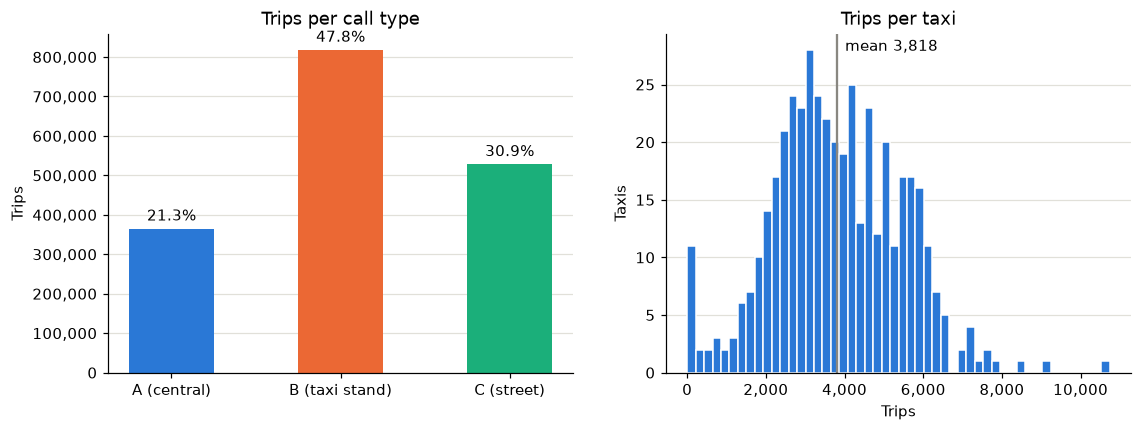

In [51]:
# Colours used in all the plots: one per call type, and blue where there is a single series
BLUE, ORANGE, GREEN, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#898781"
CALL_TYPE_COLORS = [BLUE, ORANGE, GREEN]
CALL_TYPE_NAMES = {"A": "A (central)", "B": "B (taxi stand)", "C": "C (street)"}

call_types = trips["CALL_TYPE"].value_counts().sort_index()
trips_per_taxi = trips["TAXI_ID"].value_counts()
print(trips_per_taxi.describe().round(0))

fig, (left, right) = plt.subplots(1, 2, figsize=(12, 4))

bars = left.bar(call_types.index.map(CALL_TYPE_NAMES), call_types, width=0.5, color=CALL_TYPE_COLORS)
left.bar_label(bars, labels=[f"{share:.1%}" for share in call_types / len(trips)], padding=3)
left.set(title="Trips per call type", ylabel="Trips")
left.yaxis.set_major_formatter("{x:,.0f}")

right.hist(trips_per_taxi, bins=50, color=BLUE, edgecolor="white")
right.axvline(trips_per_taxi.mean(), color=GREY)
right.annotate(f"mean {trips_per_taxi.mean():,.0f}", (trips_per_taxi.mean(), 0.95),
               xycoords=("data", "axes fraction"), xytext=(5, 0), textcoords="offset points")
right.set(title="Trips per taxi", xlabel="Trips", ylabel="Taxis")
right.xaxis.set_major_formatter("{x:,.0f}")
plt.show()

### 4.2 When the trips start

The data covers exactly one year, 1 July 2013 to 30 June 2014, with trips on all 365 days. The months are
fairly even, from 126,000 trips in August to 162,000 in May. Friday and Saturday are the busiest days, and
about half of all trips start between 08 and 18 UTC.

First trip: 2013-07-01 00:00:53
Last trip:  2014-06-30 23:59:56


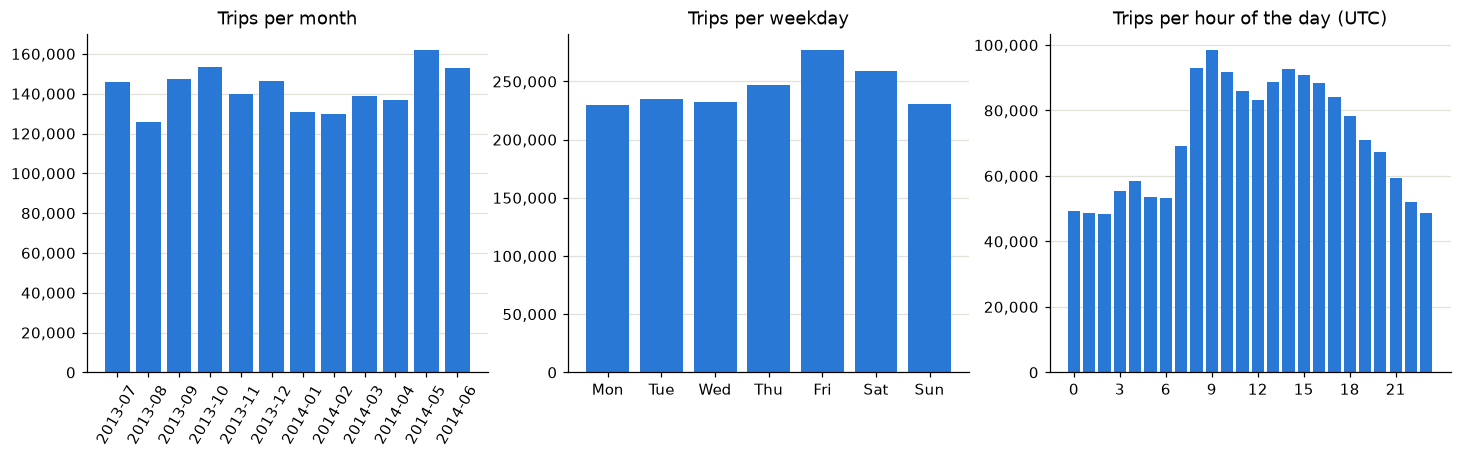

In [52]:
start = trips["START_TIME"]
print("First trip:", start.min())
print("Last trip: ", start.max())

per_month = start.dt.strftime("%Y-%m").value_counts().sort_index()
per_weekday = start.dt.dayofweek.value_counts().sort_index()
per_hour = start.dt.hour.value_counts().sort_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].bar(per_month.index, per_month, color=BLUE)
axes[0].set(title="Trips per month")
axes[0].tick_params(axis="x", rotation=60)
axes[1].bar(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], per_weekday, color=BLUE)
axes[1].set(title="Trips per weekday")
axes[2].bar(per_hour.index, per_hour, color=BLUE)
axes[2].set(title="Trips per hour of the day (UTC)", xticks=range(0, 24, 3))
for ax in axes:
    ax.yaxis.set_major_formatter("{x:,.0f}")
plt.show()

The times are UTC, while Porto is on UTC+1 during summer time. This only matters for the questions about
the clock: in local time 1.8 % of the trips start on another date (task 8) and 9.2 % in another of the
six-hour bands of task 4b.

In [53]:
local_start = start.dt.tz_localize("UTC").dt.tz_convert("Europe/Lisbon")
print("Trips starting on another date in local time:  ", (local_start.dt.date != start.dt.date).sum())
print("Trips starting in another 6-hour band in local time:", (local_start.dt.hour // 6 != start.dt.hour // 6).sum())

Trips starting on another date in local time:   30473
Trips starting in another 6-hour band in local time: 157929


### 4.3 GPS points per trip

The typical trip has 41 points, which is 10 minutes. The distribution has a long tail to the right and a
spike at the very start: 30,609 trips consist of a single point.

       POINT_COUNT  DURATION_MIN
count    1710670.0     1710670.0
mean          48.8          11.9
std           45.7          11.4
min            0.0           0.0
25%           28.0           6.8
50%           41.0          10.0
75%           59.0          14.5
max         3881.0         970.0


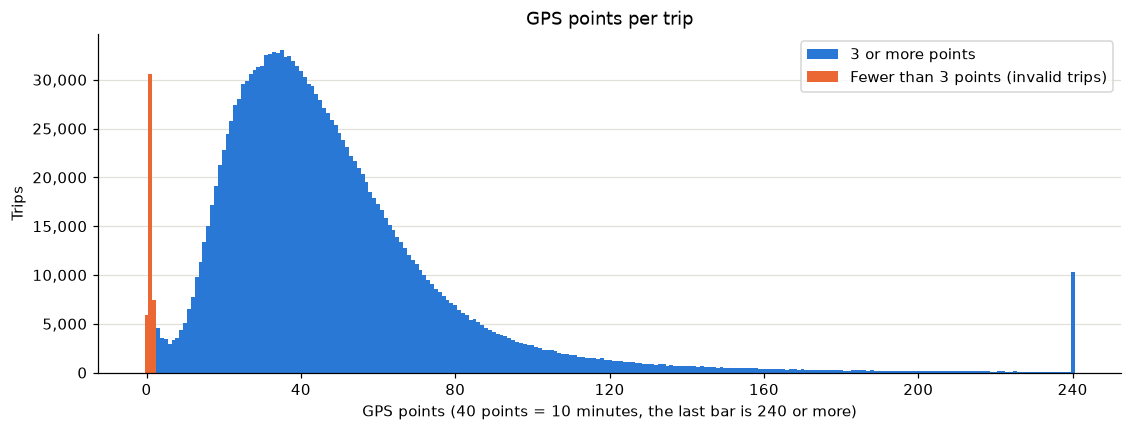

In [54]:
print(trips[["POINT_COUNT", "DURATION_MIN"]].describe().round(1))

# Trips of an hour or more (240 points - 1 hour) are gathered in the last bar
per_count = trips["POINT_COUNT"].clip(upper=240).value_counts().sort_index()
invalid_counts = per_count.index < 3

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(per_count.index[~invalid_counts], per_count[~invalid_counts], width=1, color=BLUE, label="3 or more points")
ax.bar(per_count.index[invalid_counts], per_count[invalid_counts], width=1, color=ORANGE,
       label="Fewer than 3 points (invalid trips)")
ax.set(title="GPS points per trip", xlabel="GPS points (40 points = 10 minutes, the last bar is 240 or more)",
       ylabel="Trips", xticks=range(0, 241, 40))
ax.yaxis.set_major_formatter("{x:,.0f}")
ax.legend()
plt.show()

## 5. Relationships between the columns

### 5.1 Call type and time of day

Street trips (`C`) follow a different rhythm from the other two call types: 32 % of them start between
00 and 06, against 12 % of the `A` and `B` trips, which peak in the morning. The table is what Part 2
task 4b asks for, computed here directly from the CSV, so it also works as a check of that query.

In [55]:
time_band = pd.cut(start.dt.hour, [0, 6, 12, 18, 24], right=False, labels=["00-06", "06-12", "12-18", "18-24"])
(100 * pd.crosstab(trips["CALL_TYPE"], time_band.rename("Share of trips (%)"), normalize="index")).round(1)

Share of trips (%),00-06,06-12,12-18,18-24
CALL_TYPE,,,,
A,11.9,33.4,32.2,22.6
B,12.2,30.1,34.5,23.2
C,32.3,23.4,24.4,20.0


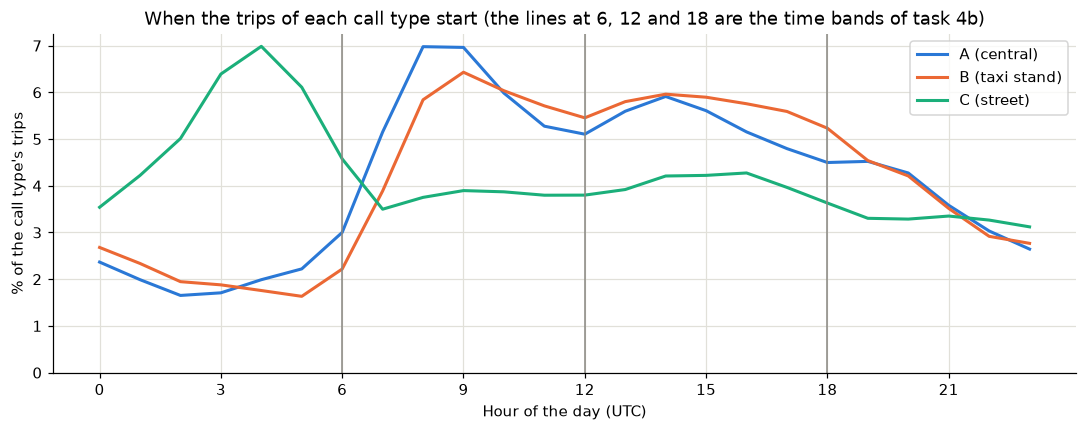

In [56]:
per_hour_and_type = 100 * pd.crosstab(start.dt.hour, trips["CALL_TYPE"], normalize="columns")

ax = per_hour_and_type.rename(columns=CALL_TYPE_NAMES).plot(figsize=(12, 4), color=CALL_TYPE_COLORS, linewidth=2)
for band_start in (6, 12, 18):
    ax.axvline(band_start, color=GREY, linewidth=1)
ax.set(title="When the trips of each call type start (the lines at 6, 12 and 18 are the time bands of task 4b)",
       xlabel="Hour of the day (UTC)", ylabel="% of the call type's trips", xticks=range(0, 24, 3), ylim=0)
ax.legend(title=None)
plt.show()

### 5.2 Who has the invalid trips?

The trips with fewer than 3 points are not evenly spread. 70 % of them are street trips: 5.8 % of the `C`
trips are invalid, against 0.7 % and 1.3 % of the `A` and `B` trips. They are also concentrated on a few
taxis. The median taxi has 1.2 % invalid trips, but taxi 20000080, the one with the most trips of all, has
60.8 %. The ranking of taxis by number of trips (task 3) is therefore partly a ranking of who registers the
most stubs. Trip duration hardly differs between the call types.

In [57]:
invalid = trips["POINT_COUNT"] < 3

by_call_type = trips.groupby("CALL_TYPE").agg(trips=("TRIP_ID", "size"), median_minutes=("DURATION_MIN", "median"),
                                              mean_minutes=("DURATION_MIN", "mean"))
by_call_type["invalid trips"] = invalid.groupby(trips["CALL_TYPE"]).sum()
by_call_type["invalid %"] = 100 * by_call_type["invalid trips"] / by_call_type["trips"]
by_call_type.round(1)

,trips,median_minutes,mean_minutes,invalid trips,invalid %
CALL_TYPE,,,,,
A,364770,11.0,12.5,2600,0.7
B,817881,9.8,11.1,10435,1.3
C,528019,10.0,12.9,30869,5.8


In [58]:
by_taxi = pd.DataFrame({"trips": trips["TAXI_ID"].value_counts(), "invalid trips": invalid.groupby(trips["TAXI_ID"]).sum()})
by_taxi["invalid %"] = (100 * by_taxi["invalid trips"] / by_taxi["trips"]).round(1)
print("Median share of invalid trips per taxi: %.1f %%" % by_taxi["invalid %"].median())
by_taxi.nlargest(5, "trips")

Median share of invalid trips per taxi: 1.2 %


,trips,invalid trips,invalid %
TAXI_ID,,,
20000080,10746,6535,60.8
20000403,9238,1722,18.6
20000066,8449,2497,29.6
20000364,7821,551,7.0
20000483,7729,106,1.4


## 6. Outliers

### 6.1 Very long trips

10,094 trips (0.6 %) last more than an hour and 403 more than four hours, the longest 16 hours. The data
cannot tell us whether these are real trips or a taximeter left running, so we keep them. They are few,
but they weigh heavily in the total hours per taxi (task 5) and among the midnight crossers (task 8).

In [59]:
for hours in (1, 4, 8):
    print("Trips longer than %d h:" % hours, (trips["DURATION_MIN"] > 60 * hours).sum())

trips.nlargest(5, "POINT_COUNT")[["TRIP_ID", "CALL_TYPE", "TAXI_ID", "START_TIME", "POINT_COUNT", "DURATION_MIN"]]

Trips longer than 1 h: 10094
Trips longer than 4 h: 403
Trips longer than 8 h: 52


,TRIP_ID,CALL_TYPE,TAXI_ID,START_TIME,POINT_COUNT,DURATION_MIN
1093727,1393061275620000681,C,20000681,2014-02-22 09:27:55,3881,970.00
1492417,1400312076620000562,C,20000562,2014-05-17 07:34:36,3872,967.75
578581,1383293324620000520,B,20000520,2013-11-01 08:08:44,3836,958.75
224510,1376892235620000086,C,20000086,2013-08-19 06:03:55,3590,897.25
147121,1375289927620000902,C,20000902,2013-07-31 16:58:47,3571,892.50


### 6.2 Where the GPS points are

The points draw the street network of Porto, which confirms that the coordinates are `[longitude, latitude]`
and that the sample is sound. 0.73 % of the points lie outside the Porto area, but they belong to only 39 of
the 34,101 sampled trips and form continuous routes along the motorways, south to the Lisbon area and to the
north-east of Portugal. These are real long-distance trips and not GPS errors, so no point is removed because
of its position.

          LON        LAT
min -9.381600  38.769624
50% -8.614629  41.157801
max -6.758604  42.041592
Points outside the Porto area: 12088 (0.73 %) from 39 trips


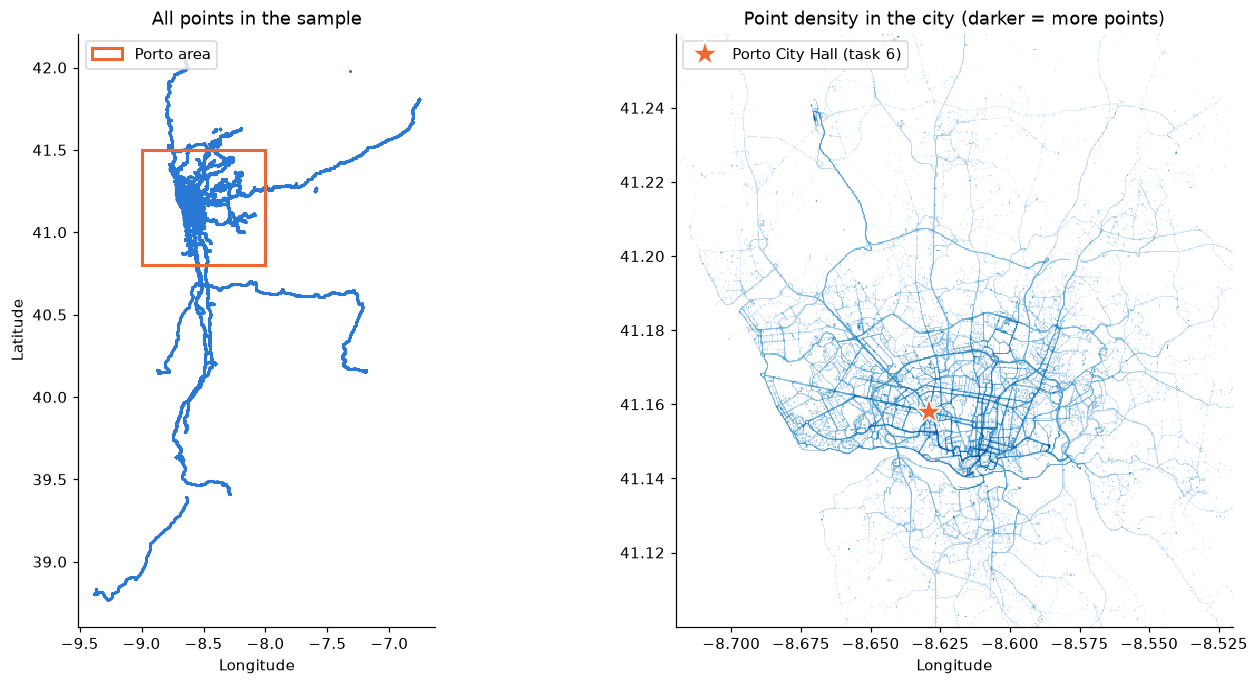

In [60]:
CITY_HALL = (-8.62911, 41.15794)  # (longitude, latitude), from Part 2 task 6
ASPECT = 1.33                     # one degree of longitude is about 1/1.33 of a degree of latitude at 41 degrees north

in_porto_area = points["LON"].between(-9.0, -8.0) & points["LAT"].between(40.8, 41.5)
print(points[["LON", "LAT"]].describe().loc[["min", "50%", "max"]])
print("Points outside the Porto area: %d (%.2f %%) from %d trips" % (
    (~in_porto_area).sum(), 100 * (~in_porto_area).mean(), points.loc[~in_porto_area, "TRIP_NO"].nunique()))

fig, (left, right) = plt.subplots(1, 2, figsize=(15, 7))

left.scatter(points["LON"], points["LAT"], s=1, color=BLUE)
left.add_patch(plt.Rectangle((-9.0, 40.8), 1.0, 0.7, fill=False, edgecolor=ORANGE, linewidth=2, label="Porto area"))
left.set(title="All points in the sample", xlabel="Longitude", ylabel="Latitude", aspect=ASPECT)
left.legend(loc="upper left")

city = points[points["LON"].between(-8.72, -8.52) & points["LAT"].between(41.10, 41.26)]
right.hist2d(city["LON"], city["LAT"], bins=500, norm="log", cmap="Blues")
right.plot(*CITY_HALL, marker="*", markersize=18, color=ORANGE, markeredgecolor="white", linestyle="none",
           label="Porto City Hall (task 6)")
right.set(title="Point density in the city (darker = more points)", xlabel="Longitude", aspect=ASPECT)
right.legend(loc="upper left")
for ax in (left, right):
    ax.grid(False)
plt.show()

### 6.3 Jumps between consecutive points

The median step between two points is 89 m, which is 21 km/h, and a quarter of the steps are shorter than
16 m (the taxi is standing still). 1.0 % of the steps are longer than 500 m, more than the motorway speed
limit allows in 15 seconds. Steps over 1000 m, which no taxi can drive, are rare: 539 steps in 419 trips
(1.2 % of the trips). They come from GPS errors or from gaps where points are missing, and a gap also means
that the duration *(n - 1)* x 15 s is too short for that trip. Together these steps add less than 1 % to the
total distance, although a single trip can be far off (the longest step is 44.7 km). The import keeps every
point, and the small effect suggests that tasks 4b and 5 can use the distances without filtering.

In [61]:
# STEP_M: distance in metres from the previous point of the same trip (empty for the first point of a trip)
previous = points.groupby("TRIP_NO")[["LAT", "LON"]].shift()
has_previous = previous["LAT"].notna()
points.loc[has_previous, "STEP_M"] = haversine_vector(
    previous[has_previous].to_numpy(), points.loc[has_previous, ["LAT", "LON"]].to_numpy(), Unit.METERS)
print(points["STEP_M"].describe().round(1))

total_km = points["STEP_M"].sum() / 1000
km_without_jumps = points.loc[points["STEP_M"] <= 1000, "STEP_M"].sum() / 1000
print("\nTotal distance in the sample: %.0f km, or %.0f km without the steps over 1000 m" % (total_km, km_without_jumps))

pd.DataFrame(
    [(limit, limit / SECONDS_BETWEEN_POINTS * 3.6, (points["STEP_M"] > limit).sum(),
      points.loc[points["STEP_M"] > limit, "TRIP_NO"].nunique()) for limit in (500, 1000, 5000)],
    columns=["Step longer than (m)", "Speed needed (km/h)", "Steps", "Trips"])

count    1624901.0
mean         115.6
std          141.4
min            0.0
25%           15.8
50%           88.5
75%          168.5
max        44697.5
Name: STEP_M, dtype: float64

Total distance in the sample: 187897 km, or 186421 km without the steps over 1000 m


,Step longer than (m),Speed needed (km/h),Steps,Trips
0,500,120.0,15927,5242
1,1000,240.0,539,419
2,5000,1200.0,62,50


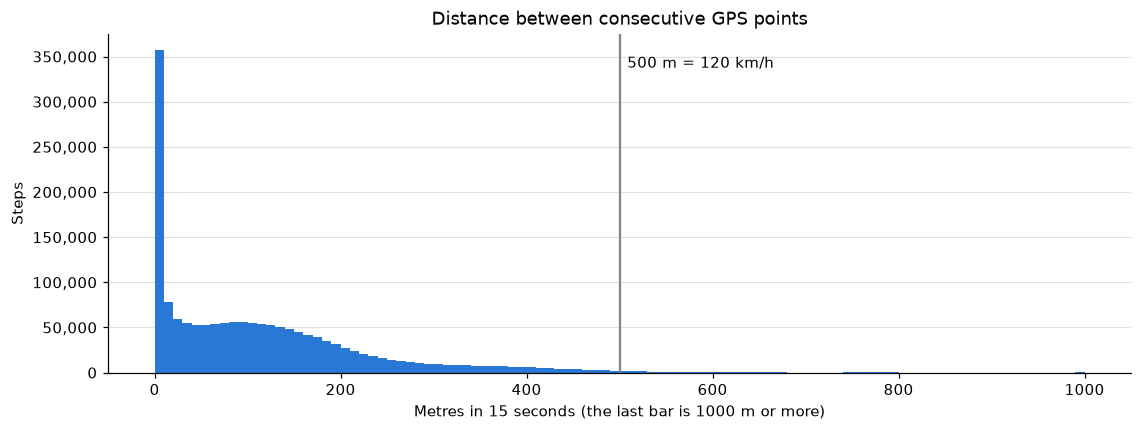

In [62]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(points["STEP_M"].clip(upper=1000), bins=100, color=BLUE)
ax.axvline(500, color=GREY)
ax.annotate("500 m = 120 km/h", (500, 0.9), xycoords=("data", "axes fraction"), xytext=(5, 0), textcoords="offset points")
ax.set(title="Distance between consecutive GPS points", ylabel="Steps",
       xlabel="Metres in 15 seconds (the last bar is 1000 m or more)")
ax.yaxis.set_major_formatter("{x:,.0f}")
plt.show()

## 7. Summary: what the findings mean for the import

The import removes as little as possible. Only the rows with a duplicated `TRIP_ID` are skipped and `DAY_TYPE` dropped as it only leads to confusion. Everything
else is kept and can be filtered in the queries of Part 2.

In [63]:
summary = pd.DataFrame([
    ("TRIP_ID already used by another row", trips.duplicated("TRIP_ID").sum(), "Keep the row with the most GPS points, skip the others"),
    ("Call type B without ORIGIN_STAND", ((trips["CALL_TYPE"] == "B") & trips["ORIGIN_STAND"].isna()).sum(), "Keep, origin_stand is NULL"),
    ("MISSING_DATA is True", trips["MISSING_DATA"].sum(), "Keep, True is really missing data, False guarantees nothing"),
    ("Empty POLYLINE", (trips["POINT_COUNT"] == 0).sum(), "Keep, with point_count 0 and no rows in gps_point"),
    ("Fewer than 3 GPS points, including the empty ones", (trips["POINT_COUNT"] < 3).sum(), "Keep, useful for task 7 query"),
    ("DAY_TYPE is always A", (trips["DAY_TYPE"] == "A").sum(), "Drop the column, only leads to confusion"),
    ("Longer than 4 hours", (trips["DURATION_MIN"] > 240).sum(), "Keep"),
], columns=["Issue", "Rows", "Handling in part1_import.py"])
summary.insert(2, "% of rows", (100 * summary["Rows"] / len(trips)).round(3))

with pd.option_context("display.max_colwidth", None):
    display(summary)

,Issue,Rows,% of rows,Handling in part1_import.py
0,TRIP_ID already used by another row,81,0.005,"Keep the row with the most GPS points, skip the others"
1,Call type B without ORIGIN_STAND,11302,0.661,"Keep, origin_stand is NULL"
2,MISSING_DATA is True,10,0.001,"Keep, True is really missing data, False guarantees nothing"
3,Empty POLYLINE,5901,0.345,"Keep, with point_count 0 and no rows in gps_point"
4,"Fewer than 3 GPS points, including the empty ones",43904,2.566,"Keep, useful for task 7 query"
5,DAY_TYPE is always A,1710670,100.000,"Drop the column, only leads to confusion"
6,Longer than 4 hours,403,0.024,Keep


What we take with us to Part 2:

- **Invalid trips are in the database.** Trips with fewer than 3 points have little or no duration and distance,
  and they are concentrated on street trips and a few taxis (5.2). Queries with averages must decide whether to count them.
- **Times are UTC.** In Porto local time 9.2 % of the trips fall in another time band (task 4b) and 1.8 % on another date (task 8).
- **GPS outliers are few.** Points far from Porto are real long trips (6.2), and impossible jumps add less than 1 % to the distance (6.3).
- **`MISSING_DATA` is stored but not very useful.** A `True` value in `MISSING_DATA` is a real signal for gaps, but `False` guarantees nothing.
- **`DAY_TYPE` is dropped.** The `DAY_TYPE` is always `A` no matter what, even on actual holidays. So a query using this field would only assert false statistics on actual holidays.